In [ ]:
import numpy as np
import rasterio
import pyproj
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from skimage.transform import resize
import sys
sys.path.insert(0, '../')
from pysheds.grid import Grid
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_palette('pastel')

%matplotlib inline

In [ ]:
FILE = '../data/dem.tif'
grid = Grid.from_raster(FILE)
dem = grid.read_raster(FILE)

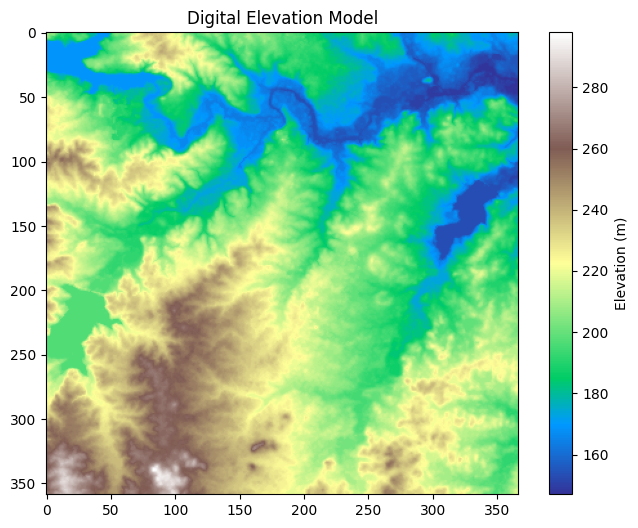

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(dem, cmap='terrain', zorder=1)
plt.colorbar(im, label='Elevation (m)')
plt.title('Digital Elevation Model')
plt.show()

In [ ]:
# DEM Processing Steps
dem_filled = grid.fill_pits(dem)
dem_flooded = grid.fill_depressions(dem_filled)
dem_conditioned = grid.resolve_flats(dem_flooded)

dirmap = (64, 128, 1, 2, 4, 8, 16, 32)
# Pour point cooridnates (longitude, latitude)
x, y = -97.294167, 32.73750

# Generate Flow Direction
fdir = grid.flowdir(dem_conditioned, dirmap=dirmap)

# Option 2: Import fdir from a raster file
# fdir = grid.read_ascii('../data/dir.asc', metadata={'dirmap': dirmap})

# Delineate the Catchment
# Note: 'xytype' can be 'label' or 'coordinate'
catch = grid.catchment(x=x, y=y, fdir=fdir, dirmap=dirmap, 
                       xytype='label', algorithm='iterative')

# Clip the Grid to the Catchment
grid.clip_to(catch)

Text(0.5, 1.0, 'Clipped Catchment DEM')

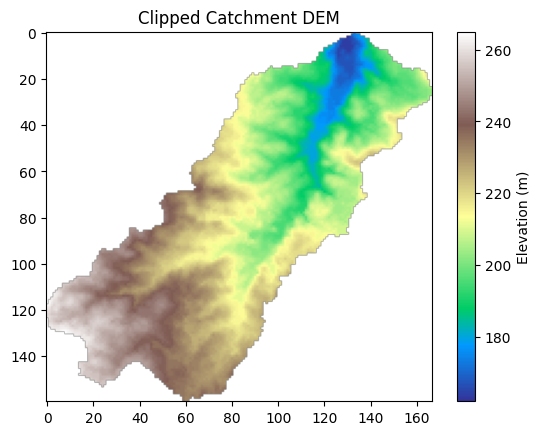

In [51]:
# grid.view() returns a Raster clipped to the current viewfinder (the catchment)
clipped_dem = grid.view(dem)

plt.imshow(np.where(clipped_dem.mask, clipped_dem, np.nan), cmap='terrain')
plt.colorbar(label='Elevation (m)')
plt.title('Clipped Catchment DEM')

In [52]:
# Importing and visualizing impervious data
# Data source: https://www.pasda.psu.edu/download/usgs/NLCD2011/ 
# Data file: nlcd_2011_impervious_2011_edition_2014_10_10.zip
impervious = grid.read_raster("../data/impervious_data.img", window=grid.bbox, window_crs=grid.crs)

# Plot windowed impervious area

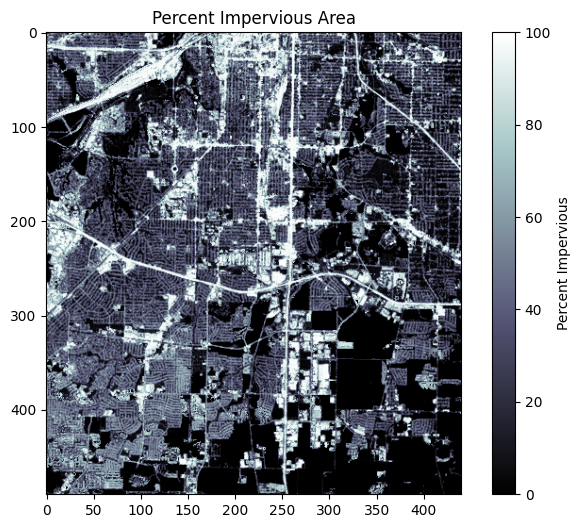

In [54]:
fig, ax = plt.subplots(figsize=(8,6))
plt.imshow(impervious, cmap='bone', zorder=1)
plt.colorbar(label='Percent Impervious')
plt.title('Percent Impervious Area')
plt.show()

# Clip to catchment (nearest neighbor)

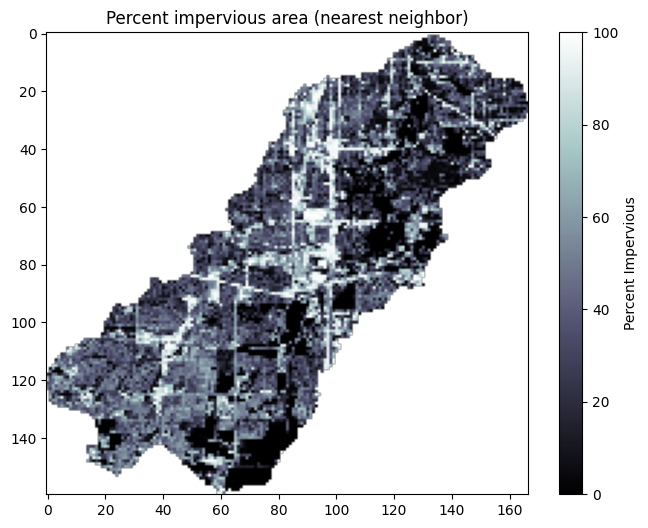

In [55]:
fig, ax = plt.subplots(figsize=(8,6))
# Using 'nearest' interpolation on the impervious data
# We force float64 so that np.nan is representable
interpolated_impervious = grid.view(impervious, interpolation='nearest', 
                                    nodata=np.nan, dtype=np.float64)

plt.imshow(interpolated_impervious, cmap='bone', zorder=1)
plt.colorbar(label='Percent Impervious')
plt.title('Percent impervious area (nearest neighbor)')
plt.show()

# Clip to catchment (linear interpolation)

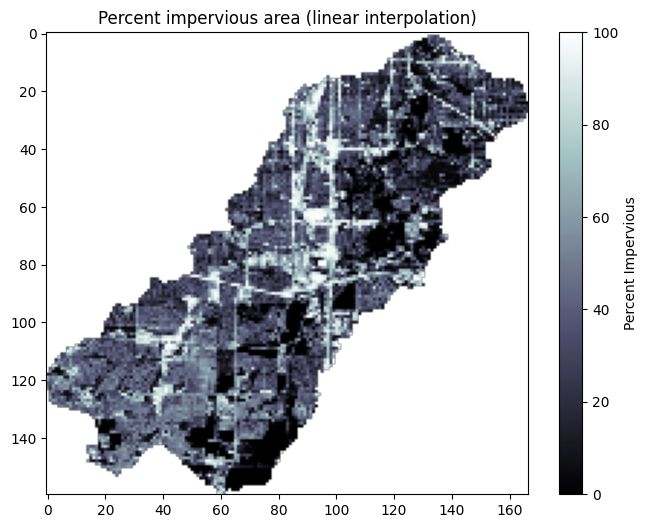

In [56]:
fig, ax = plt.subplots(figsize=(8,6))
# Using 'linear' interpolation for smoother transitions between pixels
interpolated_impervious = grid.view(impervious, interpolation='linear', nodata=np.nan)

plt.imshow(interpolated_impervious, cmap='bone', zorder=1)
plt.colorbar(label='Percent Impervious')
plt.title('Percent impervious area (linear interpolation)')
plt.show()

 # DEM View

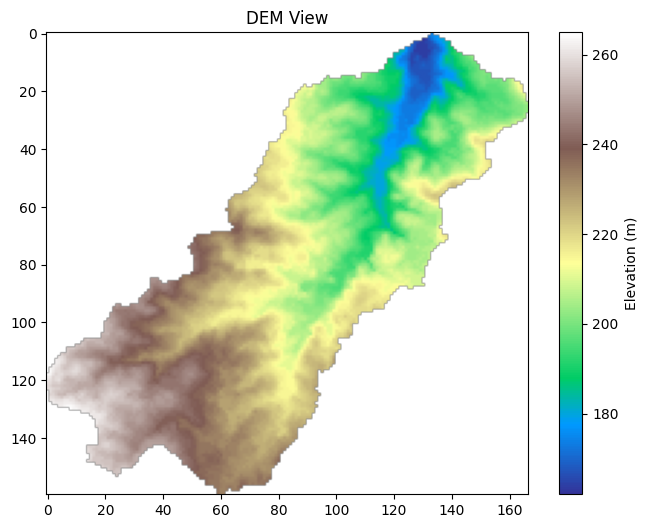

In [57]:
fig, ax = plt.subplots(figsize=(8,6))
# Visualizing the DEM through the same catchment "lens"
interpolated_dem = grid.view(dem, interpolation='linear', nodata=np.nan)

plt.imshow(interpolated_dem, cmap='terrain', zorder=1)
plt.colorbar(label='Elevation (m)')
plt.title('DEM View')
plt.show()

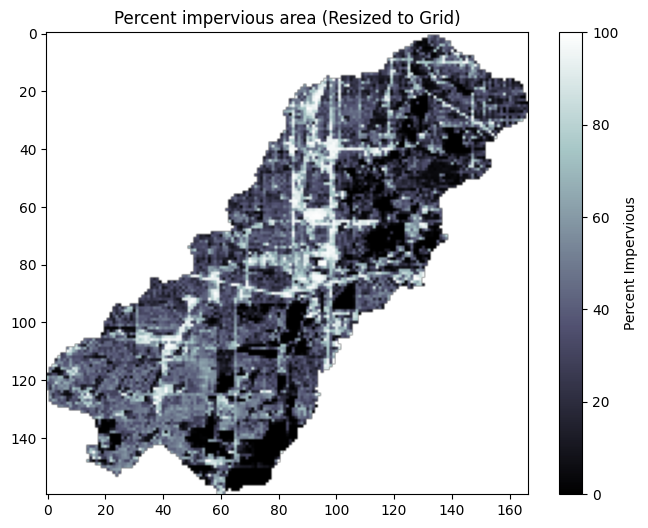

In [58]:

impervious_resized = grid.view(impervious, interpolation='linear', 
                               nodata=np.nan, dtype=np.float64)

fig, ax = plt.subplots(figsize=(8,6))
plt.imshow(impervious_resized, cmap='bone', zorder=1)
plt.colorbar(label='Percent Impervious')
plt.title('Percent impervious area (Resized to Grid)')
plt.show()